In [1]:
pip install yfinance


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 949.2/949.2 kB 15.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 112.8 MB/s eta 0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15636 sha256=f847eaea7fcc0fbd1efffe7e45d2675e256ba26e7bd796a2a01679842dba77b4
  Stored in directory: /root/.cache/pip/wheels/cc/bd/6f/664d62c99327abeef7d86489e6631cbf45b56fbf7ef1d6ef00
  Created wheel for peewee: filename=peewee-3.18.2-cp312-cp312-linux_x86_64.whl size=936669 sha256=afd141ff71536c891ea6e3879dfe87b2af544253b0b8d8ab43346b6485a825ff
  Stored in directory: /root/.cache/pip/wheels/d1/df/a9/0

In [2]:
!pip install tensorflow

  Using cached wheel-0.45.1-py3-none-any.whl.metadata (2.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 120.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 123.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 16.3 MB/s eta 0:00:00
Using cached wheel-0.45.1-py3-none-any.whl (72 kB)


In [3]:
import numpy as np
import yfinance as yf
from datetime import datetime, timedelta
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os


In [4]:

# 获取昨天的日期
end_date = datetime.today() - timedelta(days=1)
start_date = end_date - timedelta(days=365 * 3)

# 格式化为字符串形式（yfinance需要）
start_str = start_date.strftime('%Y-%m-%d')
end_str = end_date.strftime('%Y-%m-%d')

# 下载江西铜业的股票数据
ticker = "600362.SS"
data = yf.download(ticker, start=start_str, end=end_str)

# 保存为CSV文件
data.to_csv('recent_stock_prices.csv')
print(f"数据已保存到 recent_stock_prices.csv（从 {start_str} 到 {end_str}）")

import pandas as pd

pf = pd.read_csv("recent_stock_prices.csv")
print(pf.head())

# 加载原始 CSV 文件
try:
    data = pd.read_csv('recent_stock_prices.csv')
    print("CSV 数据预览：")
    print(data.head())
except pd.errors.EmptyDataError:
    print("CSV 文件为空，请检查数据来源或重新下载。")
except FileNotFoundError:
    print("文件不存在，请确认文件路径是否正确。")


/tmp/ipython-input-3040425548.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_str, end=end_str)
[*********************100%***********************]  1 of 1 completed

数据已保存到 recent_stock_prices.csv（从 2022-08-26 到 2025-08-25）
        Price               Close                High                 Low  \
0      Ticker           600362.SS           600362.SS           600362.SS   
1        Date                 NaN                 NaN                 NaN   
2  2022-08-26  15.658512115478516  15.860912927517678  15.603310458289714   
3  2022-08-29  15.520512580871582  15.575712487195158  15.235309262857443   
4  2022-08-30  15.382511138916016  15.584913732637293  15.327311229161799   

                 Open     Volume  
0           600362.SS  600362.SS  
1                 NaN        NaN  
2   15.66771239167665   15323671  
3  15.327310276578991   12065532  
4  15.502112990619223    9625195  
CSV 数据预览：
        Price               Close                High                 Low  \
0      Ticker           600362.SS           600362.SS           600362.SS   
1        Date                 NaN                 NaN                 NaN   
2  2022-08-26  15.6585121154

In [5]:

# 读取原始 CSV
df = pd.read_csv('recent_stock_prices.csv')

# 重命名列并删除前两行
df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
df = df.iloc[2:].reset_index(drop=True)

# 转换数据类型
df[['Close', 'High', 'Low', 'Open', 'Volume']] = df[['Close', 'High', 'Low', 'Open', 'Volume']].astype(float)

# 日期格式转换
df['Date'] = pd.to_datetime(df['Date'])

df.to_csv('cleaned_stock_data.csv', index=False)
print(df.head())

        Date      Close       High        Low       Open      Volume
0 2022-08-26  15.658512  15.860913  15.603310  15.667712  15323671.0
1 2022-08-29  15.520513  15.575712  15.235309  15.327310  12065532.0
2 2022-08-30  15.382511  15.584914  15.327311  15.502113   9625195.0
3 2022-08-31  15.069708  15.336511  15.051309  15.336511  14012126.0
4 2022-09-01  15.023708  15.170909  14.986909  15.078908   9664033.0


In [7]:
print(df.tail())

          Date      Close       High        Low       Open      Volume
720 2025-08-18  24.879999  25.370001  24.740000  25.370001  48072736.0
721 2025-08-19  24.510000  24.950001  24.389999  24.820000  34583662.0
722 2025-08-20  24.820000  24.930000  24.450001  24.490000  26770861.0
723 2025-08-21  24.639999  25.080000  24.559999  24.850000  22333806.0
724 2025-08-22  24.719999  24.760000  24.410000  24.600000  24467147.0


In [8]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 设置绘图风格（使用 Matplotlib 自带的样式）
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')


In [9]:
# 设置窗口大小和预测偏移
window_size = 50         # 用过去 60 天的数据预测
target_shift = 1         # 预测未来第 1 天的收盘价


In [10]:
print(plt.style.available)


['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [12]:
# 加载你的数据（假设 CSV 文件中包含 Date 和 Close 列）
df = pd.read_csv('cleaned_stock_data.csv', parse_dates=['Date'])
df.sort_values('Date', inplace=True)

# 计算 MACD 和信号线
def compute_macd(df, fast=12, slow=26, signal=9):
    df['EMA_fast'] = df['Close'].ewm(span=fast, adjust=False).mean()
    df['EMA_slow'] = df['Close'].ewm(span=slow, adjust=False).mean()
    df['MACD'] = df['EMA_fast'] - df['EMA_slow']
    df['MACD_signal'] = df['MACD'].ewm(span=signal, adjust=False).mean()
    return df

# 计算 RSI 指标
def compute_rsi(df, period=14):
    delta = df['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    rs = avg_gain / avg_loss
    df['RSI'] = 100 - (100 / (1 + rs))
    return df

# 添加技术指标
def add_technical_indicators(df):
    df = compute_macd(df)
    df = compute_rsi(df)
    df.dropna(inplace=True)
    return df

# 应用技术指标
df = add_technical_indicators(df)


In [13]:
# 添加周期性时间特征（例如：星期几、月份）
df['DayOfWeek'] = df['Date'].dt.dayofweek  # 周一=0，周日=6
df['Month'] = df['Date'].dt.month

# 转为周期性编码（sin/cos）
df['Day_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['Day_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)


In [15]:
# 原始技术指标 + 时间特征
features = ['Close', 'MACD', 'MACD_signal', 'RSI', 'Day_sin', 'Day_cos', 'Month_sin', 'Month_cos']
scaled_data = scaler.fit_transform(df[features])


In [16]:
X, y = [], []
for i in range(window_size, len(scaled_data) - target_shift):
    X.append(scaled_data[i - window_size:i])
    y.append(scaled_data[i + target_shift][0])  # 预测收盘价


In [17]:
# 设置窗口大小和预测偏移
window_size = 60         # 用过去 60 天的数据预测
target_shift = 1         # 预测未来第 1 天的收盘价

# 选择用于训练的特征（你已经更新过了）
features = ['Close', 'MACD', 'MACD_signal', 'RSI', 'Day_sin', 'Day_cos', 'Month_sin', 'Month_cos']

# 归一化处理
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[features])

# 构建训练数据集
X, y = [], []
for i in range(window_size, len(scaled_data) - target_shift):
    X.append(scaled_data[i - window_size:i])
    y.append(scaled_data[i + target_shift][0])  # 预测收盘价

X, y = np.array(X), np.array(y)

# 划分训练集和验证集
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)


In [18]:
!pip install tensorflow


In [19]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 构建模型函数
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(64, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(LSTM(32))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

# 构建模型（确保 X_train 已定义）
model = build_lstm_model((X_train.shape[1], X_train.shape[2]))

# 回调函数（可选）
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True)

# 模型训练
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, checkpoint],
    verbose=1
)


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0807

17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 0.0793 - val_loss: 0.0097
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0197

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0196 - val_loss: 0.0057
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0130

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0129 - val_loss: 0.0045
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0098 - val_loss: 0.0061
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0099 - val_loss: 0.0068
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0087 - val_loss: 0.0050
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0087 - val_loss: 0.0048
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0067 - val_loss: 0.0061
Epoch 9/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0072 - val_loss: 0.0057
Epoch 10/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0061 - val_loss: 0.0061
Epoch 11/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0063 - val_loss: 0.0056
Epoch 12/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0058 - val_loss: 0.0101
Epoch 13/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0066 - val_loss: 0.0047


In [21]:
# 模型预测
y_pred = model.predict(X_val)

# 反归一化（只对 'Close' 一列）
y_val_rescaled = scaler.inverse_transform(
    np.concatenate([y_val.reshape(-1, 1), np.zeros((len(y_val), len(features)-1))], axis=1)
)[:, 0]

y_pred_rescaled = scaler.inverse_transform(
    np.concatenate([y_pred, np.zeros((len(y_pred), len(features)-1))], axis=1)
)[:, 0]


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) Liberatio

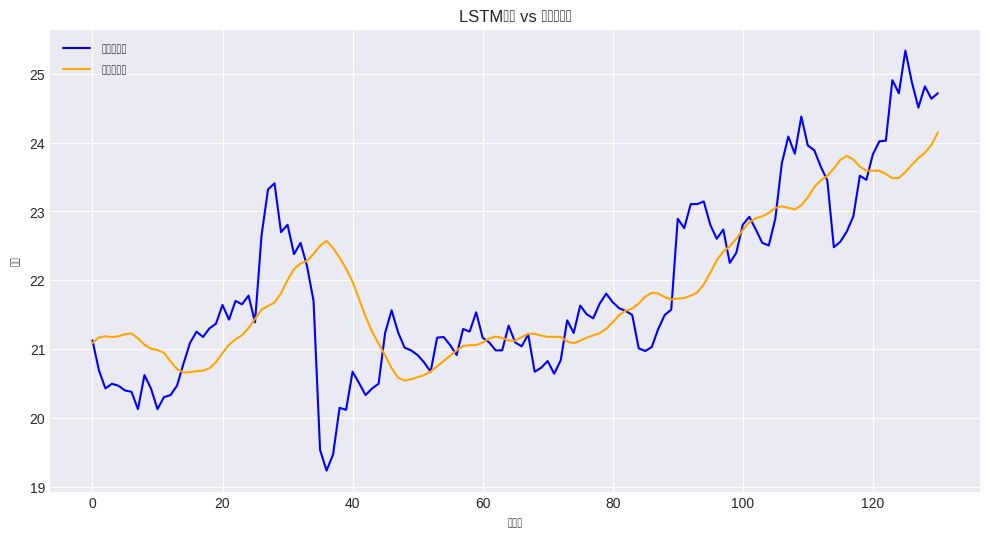

In [22]:
import matplotlib.pyplot as plt

def plot_predictions(y_true, y_pred, title='LSTM预测 vs 实际收盘价'):
    plt.figure(figsize=(12, 6))
    plt.plot(y_true, label='实际收盘价', color='blue')
    plt.plot(y_pred, label='预测收盘价', color='orange')
    plt.title(title)
    plt.xlabel('时间步')
    plt.ylabel('价格')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_predictions(y_val_rescaled, y_pred_rescaled)


/tmp/ipython-input-1643844742.py:11: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1643844742.py:11: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1643844742.py:11: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1643844742.py:11: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1643844742.py:11: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1643844742.py:11: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1643844742.py:11: UserWarning: Glyph 23454 (\N{CJK UNIFIE

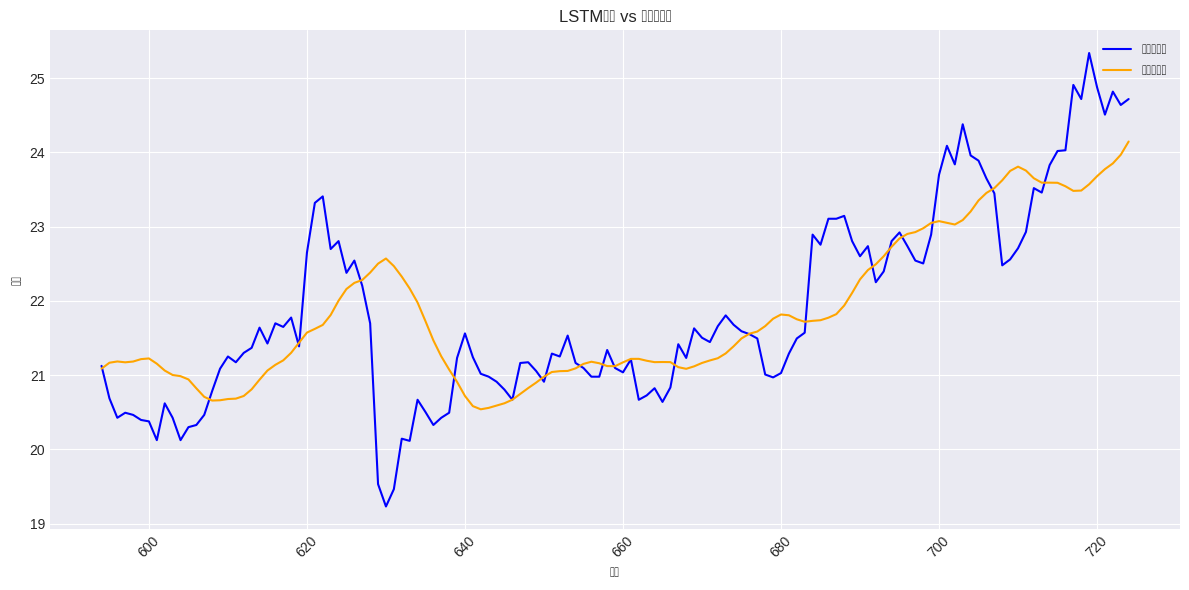

In [24]:
val_dates = df.index[-len(y_val):]  # 假设 df.index 是 datetime 类型
plt.figure(figsize=(12, 6))
plt.plot(val_dates, y_val_rescaled, label='实际收盘价', color='blue')
plt.plot(val_dates, y_pred_rescaled, label='预测收盘价', color='orange')
plt.title('LSTM预测 vs 实际收盘价')
plt.xlabel('日期')
plt.ylabel('价格')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(y_val_rescaled, y_pred_rescaled))
mae = mean_absolute_error(y_val_rescaled, y_pred_rescaled)

print(f'RMSE: {rmse:.2f}, MAE: {mae:.2f}')


RMSE: 0.86, MAE: 0.64


In [26]:
last_sequence = scaled_data[-60:]  # 假设 lookback=60
future_preds = []

for _ in range(30):  # 预测未来30天
    input_seq = last_sequence.reshape(1, 60, len(features))
    pred = model.predict(input_seq)[0, 0]
    future_preds.append(pred)

    # 更新序列
    new_row = np.zeros((1, len(features)))
    new_row[0, 0] = pred  # 只填 'Close'，其他特征可用平均值或前值
    last_sequence = np.vstack([last_sequence[1:], new_row])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━

In [31]:
future_preds_array = np.array(future_preds).reshape(-1, 1)

# 构造虚拟特征矩阵用于反归一化（只填 'Close'）
dummy = np.zeros((len(future_preds_array), len(features)-1))
future_rescaled = scaler.inverse_transform(np.hstack([future_preds_array, dummy]))[:, 0]


In [33]:
last_date = df.index[-1]  # 假设 df.index 是 datetime 类型
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30)


/tmp/ipython-input-1176801936.py:9: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1176801936.py:9: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1176801936.py:9: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1176801936.py:9: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1176801936.py:9: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1176801936.py:9: UserWarning: Glyph 26469 (\N{CJK UNIFIED IDEOGRAPH-6765}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1176801936.py:9: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOG

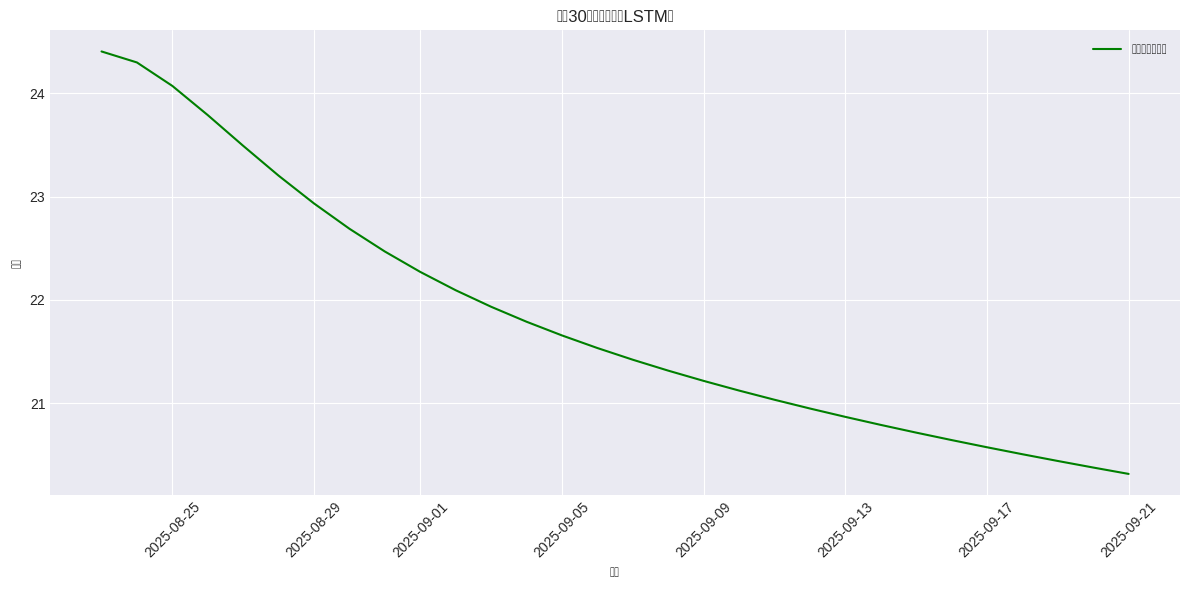

In [34]:
plt.figure(figsize=(12, 6))
plt.plot(future_dates, future_rescaled, label='未来预测收盘价', color='green')
plt.title('未来30天股价预测（LSTM）')
plt.xlabel('日期')
plt.ylabel('价格')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
%matplotlib inline


In [ ]:
%pip install yfinance

In [36]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_future_predictions(dates, values, title='未来30天股价预测（LSTM）'):
    plt.figure(figsize=(10, 6))

    # 过滤掉周末数据
    weekdays_mask = (dates.dayofweek < 5)  # 0-4 for Monday to Friday
    dates_weekdays = dates[weekdays_mask]
    values_weekdays = values[weekdays_mask]

    plt.plot(dates_weekdays, values_weekdays, label='预测值', color='green', marker='o') # 添加 marker='o'

    # 在每个数据点上添加价格数值标注
    for date, value in zip(dates_weekdays, values_weekdays):
        plt.text(date, value, f'{value:.2f}', ha='center', va='bottom', fontsize=8)

    plt.title(title)
    plt.xlabel('日期')
    plt.ylabel('价格')
    plt.grid(True)
    plt.legend()

    # 设置日期格式和间隔
    plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=3))  # 每3天一个刻度
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

/tmp/ipython-input-3447254453.py:28: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-3447254453.py:28: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-3447254453.py:28: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-3447254453.py:28: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-3447254453.py:28: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-3447254453.py:28: UserWarning: Glyph 26469 (\N{CJK UNIFIED IDEOGRAPH-6765}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-3447254453.py:28: UserWarning: Glyph 22825 (\N{CJK UNIFIE

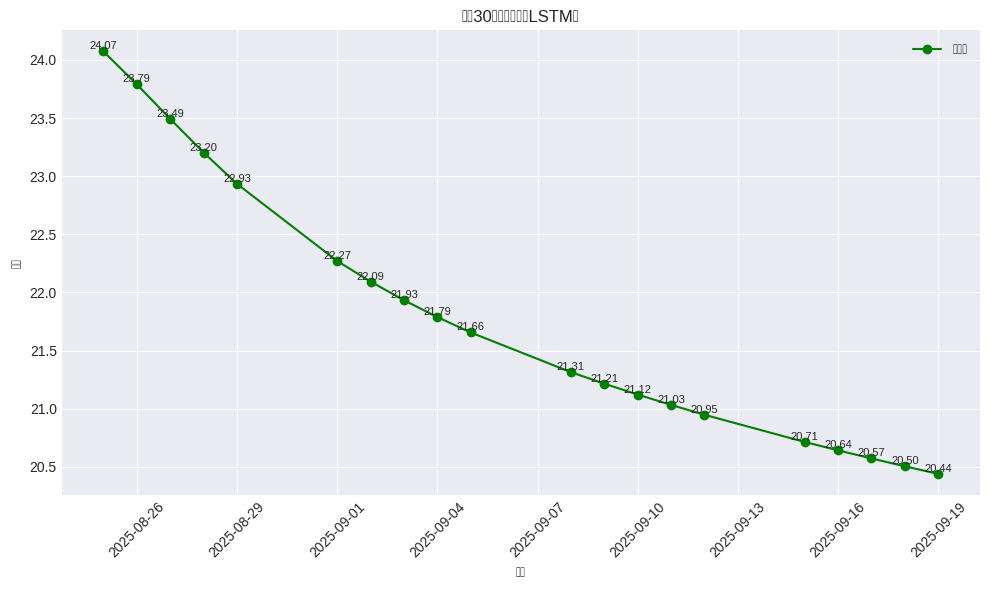

In [38]:
plot_future_predictions(future_dates, future_rescaled)